In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df = pd.read_csv("../data/processed/cleaned_retail_data.csv")

df.shape

(805549, 8)

In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805549 entries, 0 to 805548
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  int64         
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[ns]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 49.2+ MB


In [4]:
df["Revenue"] = df["Quantity"] * df["Price"]

df[["Quantity","Price","Revenue"]].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [5]:
daily_sales = (
    df.groupby(df["InvoiceDate"].dt.date)["Revenue"]
      .sum()
      .reset_index()
)

daily_sales.columns = ["Date", "Sales"]

daily_sales.head()

,Date,Sales
0,2009-12-01,44048.69
1,2009-12-02,52941.99
2,2009-12-03,67479.08
3,2009-12-04,34064.41
4,2009-12-05,9803.05


In [6]:
daily_sales.shape

(604, 2)

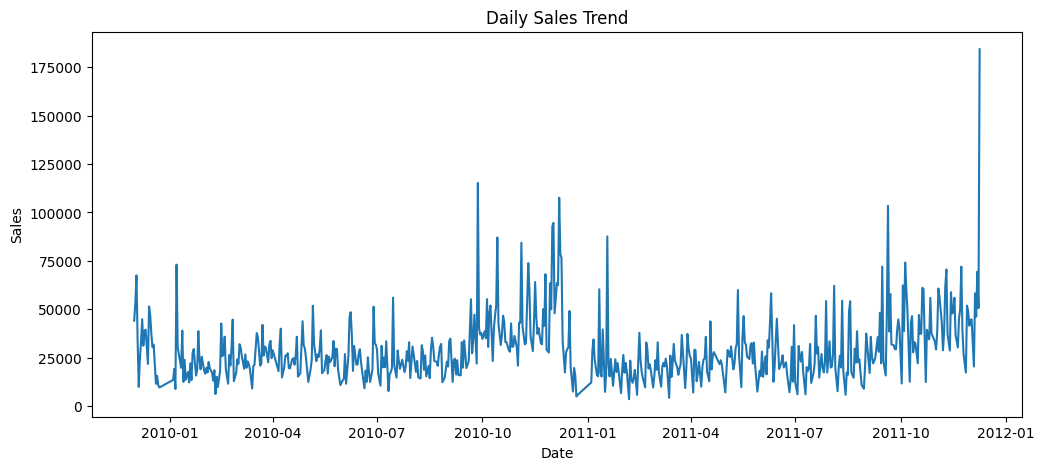

In [7]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales["Date"], daily_sales["Sales"])
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [8]:
result = adfuller(daily_sales["Sales"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.355195660077527
p-value: 0.1547832933912594


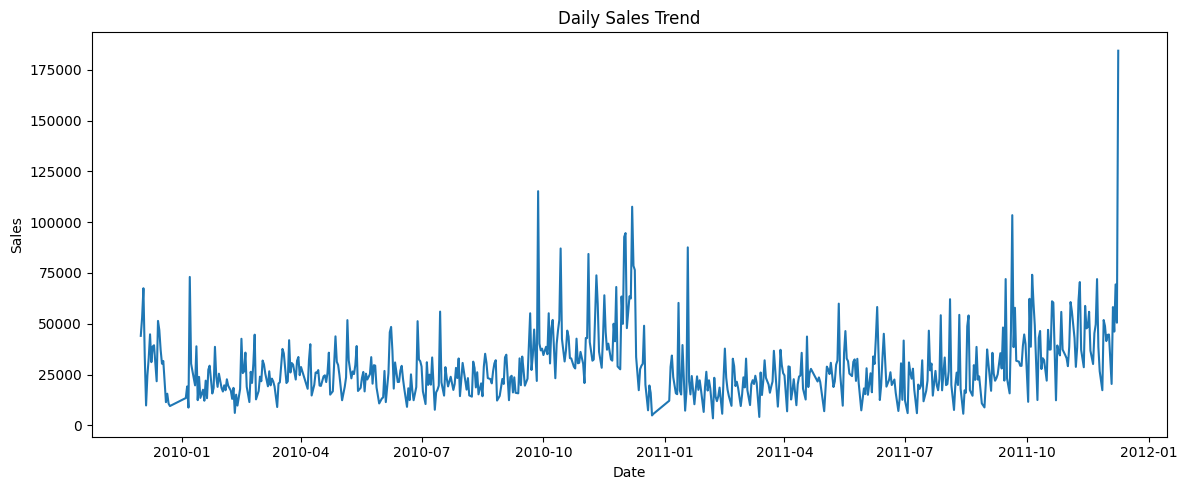

In [9]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales["Date"], daily_sales["Sales"])
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("../screenshots/daily_sales_trend.png")
plt.show()

In [10]:
daily_sales_ts = daily_sales.copy()

daily_sales_ts["Date"] = pd.to_datetime(daily_sales_ts["Date"])
daily_sales_ts = daily_sales_ts.set_index("Date")

decomposition = seasonal_decompose(
    daily_sales_ts["Sales"],
    model="additive",
    period=30
)

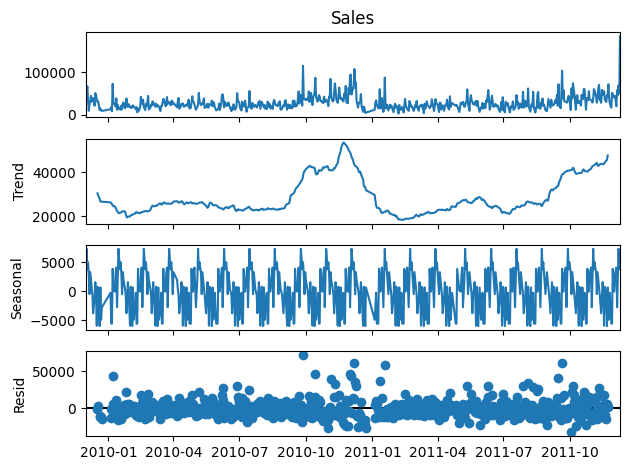

In [11]:
decomposition.plot()
plt.show()

In [12]:
daily_sales.to_csv(
    "../data/processed/daily_sales.csv",
    index=False
)

print("Daily sales dataset saved successfully!")

Daily sales dataset saved successfully!
